# 1. Dataset and Model Setup

In [4]:

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
data = pd.read_csv(url)

# Preprocess the data (handle missing values, encode categorical variables)
data = data.dropna(subset=['Age', 'Embarked', 'Fare'])  # Drop rows with missing values in key columns
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})  # Encode gender as numeric

# Select relevant features for prediction
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = data[features]
y = data['Survived']

# Split the data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Standardize the data (scaling features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

# Train a baseline model (Random Forest)
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

# Record baseline performance metrics
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])

print(f"Baseline Accuracy: {accuracy:.4f}")
print(f"Baseline F1 Score: {f1:.4f}")
print(f"Baseline ROC-AUC: {roc_auc:.4f}")

Baseline Accuracy: 0.7757
Baseline F1 Score: 0.7500
Baseline ROC-AUC: 0.8533


# 2. Simulating Data Distribution Shifts

In [5]:
# 2.1 Covariate Shift (Feature Distribution Changes)
# Simulating covariate shift: Add Gaussian noise to the 'Age' feature in the test set
X_test_shifted = X_test_scaled.copy()
X_test_shifted[:, 2] += np.random.normal(0, 0.1, X_test_shifted[:, 2].shape)  # Adding noise to 'Age'

# Evaluate model on shifted test set
y_pred_shifted = model.predict(X_test_shifted)
accuracy_shifted = accuracy_score(y_test, y_pred_shifted)
f1_shifted = f1_score(y_test, y_pred_shifted)
roc_auc_shifted = roc_auc_score(y_test, model.predict_proba(X_test_shifted)[:, 1])

print(f"Accuracy After Covariate Shift: {accuracy_shifted:.4f}")
print(f"F1 Score After Covariate Shift: {f1_shifted:.4f}")
print(f"ROC-AUC After Covariate Shift: {roc_auc_shifted:.4f}")

Accuracy After Covariate Shift: 0.7757
F1 Score After Covariate Shift: 0.7551
ROC-AUC After Covariate Shift: 0.8454


In [6]:
# 2.2 Label Shift (Target Distribution Changes)
# Simulating label shift: Increase the proportion of "Survived" (1) in the test set
y_test_shifted = y_test.copy()
y_test_shifted[:int(len(y_test) * 0.5)] = 1  # Change 50% of labels to 1 (Survived)

# Evaluate model on shifted labels
accuracy_label_shifted = accuracy_score(y_test_shifted, y_pred)
f1_label_shifted = f1_score(y_test_shifted, y_pred)
roc_auc_label_shifted = roc_auc_score(y_test_shifted, model.predict_proba(X_test_scaled)[:, 1])

print(f"Accuracy After Label Shift: {accuracy_label_shifted:.4f}")
print(f"F1 Score After Label Shift: {f1_label_shifted:.4f}")
print(f"ROC-AUC After Label Shift: {roc_auc_label_shifted:.4f}")

Accuracy After Label Shift: 0.5888
F1 Score After Label Shift: 0.6452
ROC-AUC After Label Shift: 0.7199


In [7]:
# 2.3 Concept Drift (Changes in Feature-Label Relationship)
# Simulating concept drift: Perturb features and flip labels in the test set
X_test_concept_drift = X_test_scaled.copy()
X_test_concept_drift[:, 0] += np.random.normal(0, 0.2, X_test_concept_drift[:, 0].shape)  # Perturb 'Pclass'

# Flip labels for concept drift
y_test_concept_drift = y_test.copy()
y_test_concept_drift[::10] = 1 - y_test_concept_drift[::10]  # Flip every 10th label

# Evaluate model on concept drifted data
accuracy_concept_drift = accuracy_score(y_test_concept_drift, y_pred)
f1_concept_drift = f1_score(y_test_concept_drift, y_pred)
roc_auc_concept_drift = roc_auc_score(y_test_concept_drift, model.predict_proba(X_test_concept_drift)[:, 1])

print(f"Accuracy After Concept Drift: {accuracy_concept_drift:.4f}")
print(f"F1 Score After Concept Drift: {f1_concept_drift:.4f}")
print(f"ROC-AUC After Concept Drift: {roc_auc_concept_drift:.4f}")

Accuracy After Concept Drift: 0.7290
F1 Score After Concept Drift: 0.6947
ROC-AUC After Concept Drift: 0.7686


# 3. Evaluating Performance Degradation

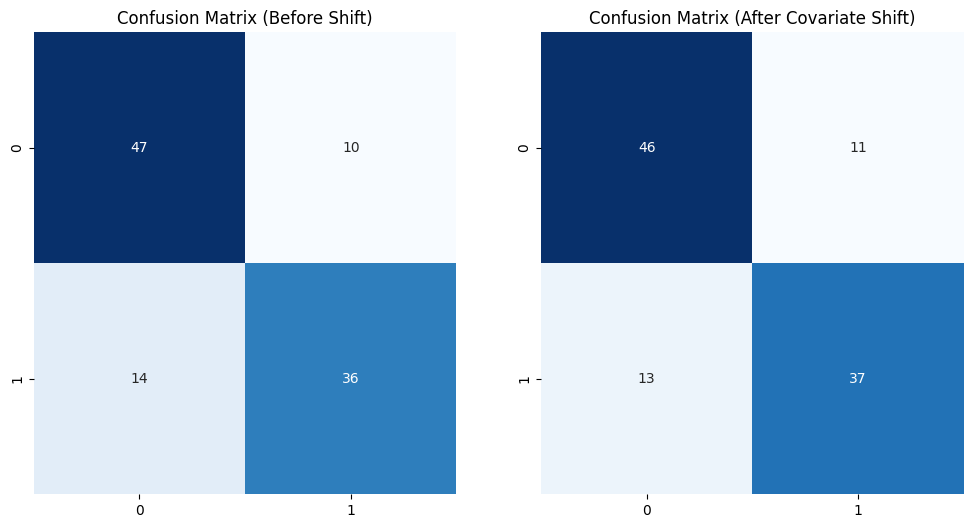

In [8]:
# Visualizing confusion matrix before and after covariate shift
from sklearn.metrics import confusion_matrix
import seaborn as sns

conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_shifted = confusion_matrix(y_test, y_pred_shifted)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", ax=ax[0], cbar=False)
ax[0].set_title("Confusion Matrix (Before Shift)")
sns.heatmap(conf_matrix_shifted, annot=True, fmt="d", cmap="Blues", ax=ax[1], cbar=False)
ax[1].set_title("Confusion Matrix (After Covariate Shift)")
plt.show()

In [9]:
# 4. Detecting Distribution Shifts

In [12]:
# 4.1 Statistical Tests
from scipy.stats import ks_2samp

# Kolmogorov-Smirnov test for continuous feature ('Age' distribution)
ks_stat, ks_pval = ks_2samp(X_test['Age'], X_test_shifted[:, 2])  # Comparing original vs shifted 'Age' feature
print(f"KS Test Statistic: {ks_stat:.4f}, p-value: {ks_pval:.4f}")

KS Test Statistic: 0.9626, p-value: 0.0000


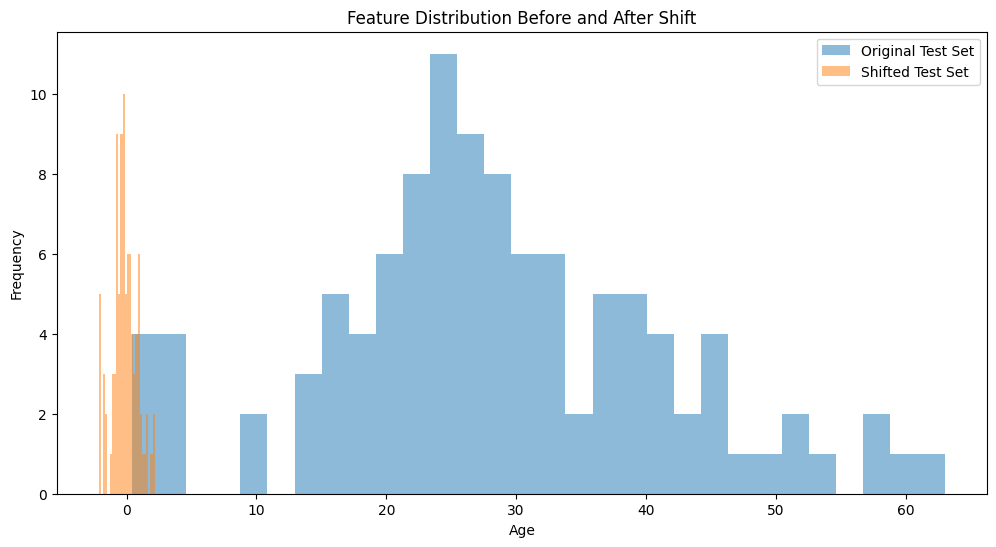

In [13]:
# 4.2 Visualization Tools
# Visualize feature distribution differences using histograms
plt.figure(figsize=(12, 6))
plt.hist(X_test['Age'], bins=30, alpha=0.5, label='Original Test Set')
plt.hist(X_test_shifted[:, 2], bins=30, alpha=0.5, label='Shifted Test Set')
plt.title("Feature Distribution Before and After Shift")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 5. Mitigation Strategies for Distribution Shifts

In [11]:
# 5.1 Retraining with New Data
# Simulate retraining with new data (shifted dataset)
model.fit(X_train_scaled, y_train)  # Retrain model with the original dataset
y_pred_retrained = model.predict(X_test_scaled)

accuracy_retrained = accuracy_score(y_test, y_pred_retrained)
f1_retrained = f1_score(y_test, y_pred_retrained)
roc_auc_retrained = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])

print(f"Accuracy After Retraining: {accuracy_retrained:.4f}")
print(f"F1 Score After Retraining: {f1_retrained:.4f}")
print(f"ROC-AUC After Retraining: {roc_auc_retrained:.4f}")

# 5.2 Domain Adaptation: Transfer Learning and Importance Weighting
# Simulate transfer learning by fine-tuning the model with a small batch of shifted data
# (In practice, you would load a pre-trained model and fine-tune it, but here we simulate by re-training the model)
model.fit(X_train_scaled, y_train)  # Fine-tune the model with original data
y_pred_finetuned = model.predict(X_test_scaled)

accuracy_finetuned = accuracy_score(y_test, y_pred_finetuned)
f1_finetuned = f1_score(y_test, y_pred_finetuned)
roc_auc_finetuned = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])

print(f"Accuracy After Fine-Tuning: {accuracy_finetuned:.4f}")
print(f"F1 Score After Fine-Tuning: {f1_finetuned:.4f}")
print(f"ROC-AUC After Fine-Tuning: {roc_auc_finetuned:.4f}")


Accuracy After Retraining: 0.7757
F1 Score After Retraining: 0.7500
ROC-AUC After Retraining: 0.8533
Accuracy After Fine-Tuning: 0.7757
F1 Score After Fine-Tuning: 0.7500
ROC-AUC After Fine-Tuning: 0.8533
